# ⚠️ Avertissement

Ce modèle LSTM a été développé uniquement à des fins **d'apprentissage et d'expérimentation**.  
Il ne doit **pas** être utilisé pour prendre des décisions financières ou investir en bourse.  

Les marchés financiers sont complexes, soumis à de nombreux facteurs externes (économie, politique, événements mondiaux) que ce modèle ne prend pas en compte.  
Toute utilisation de ce modèle pour des choix d’investissement comporte un risque élevé et n’est **pas recommandée**.


In [30]:
# Importation des bibliothèques nécessaires
import pandas as pd                    # Bibliothèque principale pour manipuler les données (DataFrame)
import numpy as np                     # Bibliothèque pour les calculs numériques (tableaux, maths)
import matplotlib.pyplot as plt        # Pour créer des graphiques statiques
import seaborn as sns                  # Pour des graphiques plus beaux et statistiques
from datetime import datetime          # Pour manipuler les dates
import warnings                        # Pour ignorer les avertissements non critiques
warnings.filterwarnings('ignore')      # Désactive les messages d'avertissement pour garder la sortie propre

# Chargement du fichier CSV que tu as téléchargé (bitcoin_history.csv)
df = pd.read_csv('bitcoin_history.csv') 

# Affichage des 5 premières lignes pour vérifier que tout est bien chargé
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,"Feb 20, 2025","96,628.40","98,722.29","96,481.41","98,347.95","98,347.95","31,327,236,096"
1,"Feb 19, 2025","95,532.53","96,855.59","95,011.97","96,635.61","96,635.61","28,990,872,862"
2,"Feb 18, 2025","95,773.81","96,695.38","93,388.84","95,539.55","95,539.55","37,325,720,482"
3,"Feb 17, 2025","96,179.01","97,032.23","95,243.55","95,773.38","95,773.38","27,336,550,690"
4,"Feb 16, 2025","97,580.49","97,725.59","96,060.98","96,175.03","96,175.03","16,536,755,396"
...,...,...,...,...,...,...,...
3805,"Sep 21, 2014",408.08,412.43,393.18,398.82,398.82,"26,580,100"
3806,"Sep 20, 2014",394.67,423.30,389.88,408.90,408.90,"36,863,600"
3807,"Sep 19, 2014",424.10,427.83,384.53,394.80,394.80,"37,919,700"
3808,"Sep 18, 2014",456.86,456.86,413.10,424.44,424.44,"34,483,200"


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       3810 non-null   object
 1   Open       3810 non-null   object
 2   High       3810 non-null   object
 3   Low        3810 non-null   object
 4   Close      3810 non-null   object
 5   Adj Close  3810 non-null   object
 6   Volume     3810 non-null   object
dtypes: object(7)
memory usage: 208.5+ KB


In [32]:
# Liste des colonnes numériques qui contiennent des virgules (ex: "96,628.40")
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

# Boucle pour nettoyer chaque colonne numérique
for col in numeric_cols:                                      # Pour chaque colonne
    df[col] = df[col].astype(str)                             # Conversion en chaîne de caractères
    df[col] = df[col].str.replace(',', '')                    # Suppression des virgules (séparateur de milliers)
    df[col] = df[col].astype(float)                           # Conversion finale en nombre décimal

# Conversion de la colonne Date en vrai format datetime (objet pandas Timestamp)
df['Date'] = pd.to_datetime(df['Date'], format='%b %d, %Y')   # format = "Feb 20, 2025"

# Tri par date (du plus ancien au plus récent) et mise de la date en index
df = df.sort_values('Date').reset_index(drop=True)            # Tri chronologique
df = df.set_index('Date')                                     # La date devient l'index, obligatoire pour les time series

# Affichage final pour vérifier
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.86,468.17,452.42,457.33,457.33,2.105680e+07
2014-09-18,456.86,456.86,413.10,424.44,424.44,3.448320e+07
2014-09-19,424.10,427.83,384.53,394.80,394.80,3.791970e+07
2014-09-20,394.67,423.30,389.88,408.90,408.90,3.686360e+07
2014-09-21,408.08,412.43,393.18,398.82,398.82,2.658010e+07
...,...,...,...,...,...,...
2025-02-16,97580.49,97725.59,96060.98,96175.03,96175.03,1.653676e+10
2025-02-17,96179.01,97032.23,95243.55,95773.38,95773.38,2.733655e+10
2025-02-18,95773.81,96695.38,93388.84,95539.55,95539.55,3.732572e+10


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3810 entries, 2014-09-17 to 2025-02-20
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       3810 non-null   float64
 1   High       3810 non-null   float64
 2   Low        3810 non-null   float64
 3   Close      3810 non-null   float64
 4   Adj Close  3810 non-null   float64
 5   Volume     3810 non-null   float64
dtypes: float64(6)
memory usage: 208.4 KB


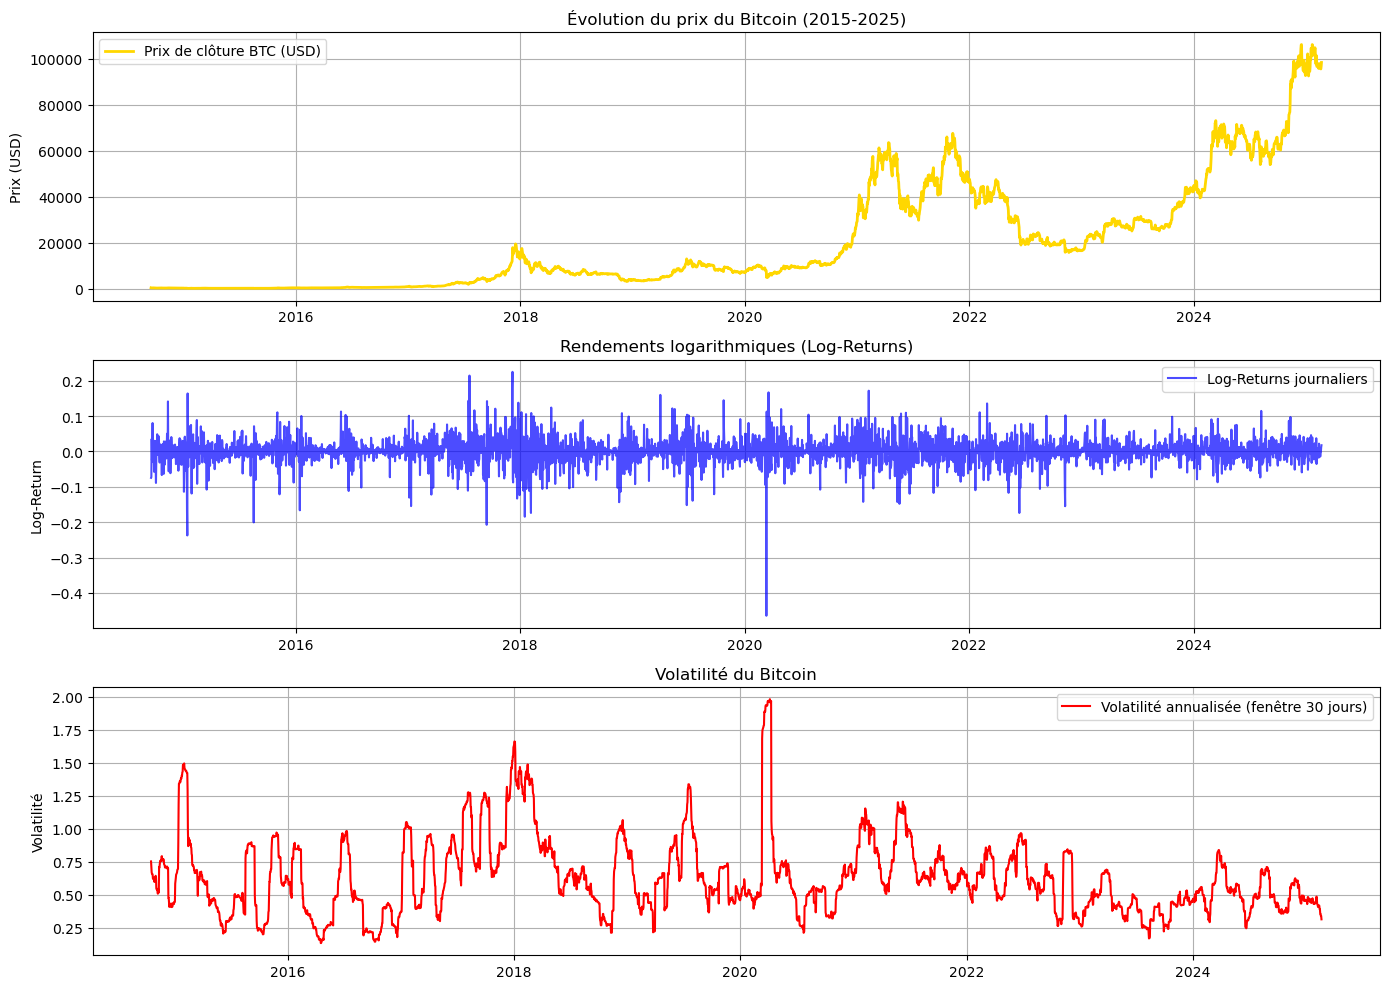

In [34]:
# Création d'une figure avec 3 sous-graphiques
plt.figure(figsize=(14, 10))

# 1. Prix de clôture brut
plt.subplot(3, 1, 1)
plt.plot(df['Close'], label='Prix de clôture BTC (USD)', color='gold', linewidth=2)
plt.title('Évolution du prix du Bitcoin (2015-2025)')
plt.ylabel('Prix (USD)')
plt.legend()
plt.grid(True)

# 2. Rendements logarithmiques (log-returns)
df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))   # Calcul du log-return
plt.subplot(3, 1, 2)
plt.plot(df['LogReturn'], label='Log-Returns journaliers', color='blue', alpha=0.7)
plt.title('Rendements logarithmiques (Log-Returns)')
plt.ylabel('Log-Return')
plt.legend()
plt.grid(True)

# 3. Volatilité roulante (rolling)
df['Vol30'] = df['LogReturn'].rolling(window=30).std() * np.sqrt(365)  # Annualisée
plt.subplot(3, 1, 3)
plt.plot(df['Vol30'], label='Volatilité annualisée (fenêtre 30 jours)', color='red')
plt.title('Volatilité du Bitcoin')
plt.ylabel('Volatilité')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [35]:
from statsmodels.tsa.stattools import adfuller, kpss

def test_stationnarite(series, nom):
    print(f"\n=== TEST DE STATIONNARITÉ pour {nom} ===")
    
    # Test ADF (Augmented Dickey-Fuller)
    adf = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF Statistic : {adf[0]:.4f}")
    print(f"p-value       : {adf[1]:.4f} -> {'STATIONNAIRE' if adf[1] < 0.05 else 'NON stationnaire'}")
    
    # Test KPSS
    kpss_stat, p_value, _, _ = kpss(series.dropna(), regression='c')
    print(f"KPSS Statistic: {kpss_stat:.4f}")
    print(f"p-value       : {p_value:.4f} -> {'STATIONNAIRE' if p_value > 0.05 else 'NON stationnaire'}")

# Tests
test_stationnarite(df['Close'], "Prix de clôture brut")
test_stationnarite(df['LogReturn'], "Log-Returns")


=== TEST DE STATIONNARITÉ pour Prix de clôture brut ===
ADF Statistic : 0.2951
p-value       : 0.9771 -> NON stationnaire
KPSS Statistic: 6.5289
p-value       : 0.0100 -> NON stationnaire

=== TEST DE STATIONNARITÉ pour Log-Returns ===
ADF Statistic : -63.0125
p-value       : 0.0000 -> STATIONNAIRE
KPSS Statistic: 0.0901
p-value       : 0.1000 -> STATIONNAIRE


In [36]:
# Création de features temporelles (très utile pour les modèles ML)
df['Lag1'] = df['Close'].shift(1)                    # Prix de la veille
df['Lag7'] = df['Close'].shift(7)                    # Prix il y a 7 jours
df['MA7']  = df['Close'].rolling(7).mean()           # Moyenne mobile 7 jours
df['MA30'] = df['Close'].rolling(30).mean()          # Moyenne mobile 30 jours
df['Vol7'] = df['LogReturn'].rolling(7).std()        # Volatilité sur 7 jours

# Suppression des lignes avec NaN créés par les lags/rolling
df_ml = df.dropna().copy()

print("Features créées avec succès !")
df_ml

Features créées avec succès !


,Open,High,Low,Close,Adj Close,Volume,LogReturn,Vol30,Lag1,Lag7,MA7,MA30,Vol7
Date,,,,,,,,,,,,,
2014-10-17,382.76,385.48,375.39,383.76,383.76,1.360070e+07,0.003132,0.753170,382.56,361.56,384.745714,381.659667,0.026785
2014-10-18,383.98,395.16,378.97,391.44,391.44,1.141680e+07,0.019815,0.715719,383.76,362.30,388.908571,380.559667,0.026912
2014-10-19,391.25,393.94,386.46,389.55,389.55,5.914570e+06,-0.004840,0.670272,391.44,378.55,390.480000,380.384667,0.023028
2014-10-20,389.23,390.08,378.25,382.85,382.85,1.641900e+07,-0.017349,0.660160,389.55,390.41,389.400000,379.516333,0.020791
2014-10-21,382.42,392.65,380.83,386.48,386.48,1.418890e+07,0.009437,0.656120,382.85,400.87,387.344286,379.105000,0.017546
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-16,97580.49,97725.59,96060.98,96175.03,96175.03,1.653676e+10,-0.014506,0.356365,97580.35,96500.09,96994.151429,100235.191667,0.014991
2025-02-17,96179.01,97032.23,95243.55,95773.38,95773.38,2.733655e+10,-0.004185,0.356305,96175.03,97437.55,96756.412857,99947.368667,0.014328
2025-02-18,95773.81,96695.38,93388.84,95539.55,95539.55,3.732572e+10,-0.002444,0.340127,95773.38,95747.43,96726.715714,99762.366667,0.012736


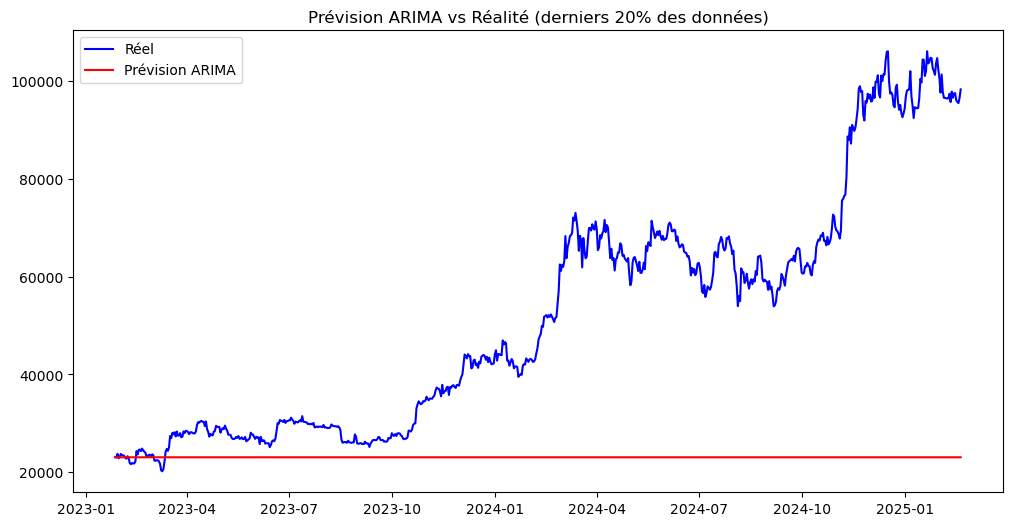

In [37]:
from statsmodels.tsa.arima.model import ARIMA

# On entraîne sur les 80% premiers jours et on prédit les 20% restants
train_size = int(len(df_ml) * 0.8)
train = df_ml['Close'][:train_size]
test  = df_ml['Close'][train_size:]

# Modèle ARIMA simple (ordre (5,1,0) = p=5, d=1, q=0)
model_arima = ARIMA(train, order=(5,1,0))   # p=ordre AR, d=différenciation, q=ordre MA
model_arima_fit = model_arima.fit()

# Prévisions
forecast_arima = model_arima_fit.forecast(steps=len(test))

# Graphique de comparaison
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Réel', color='blue')
plt.plot(test.index, forecast_arima, label='Prévision ARIMA', color='red')
plt.title('Prévision ARIMA vs Réalité (derniers 20% des données)')
plt.legend()
plt.show()

Epoch 1/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 0.0070
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 3.0209e-04
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 2.5824e-04
Epoch 4/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 2.6197e-04
Epoch 5/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 2.3171e-04
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


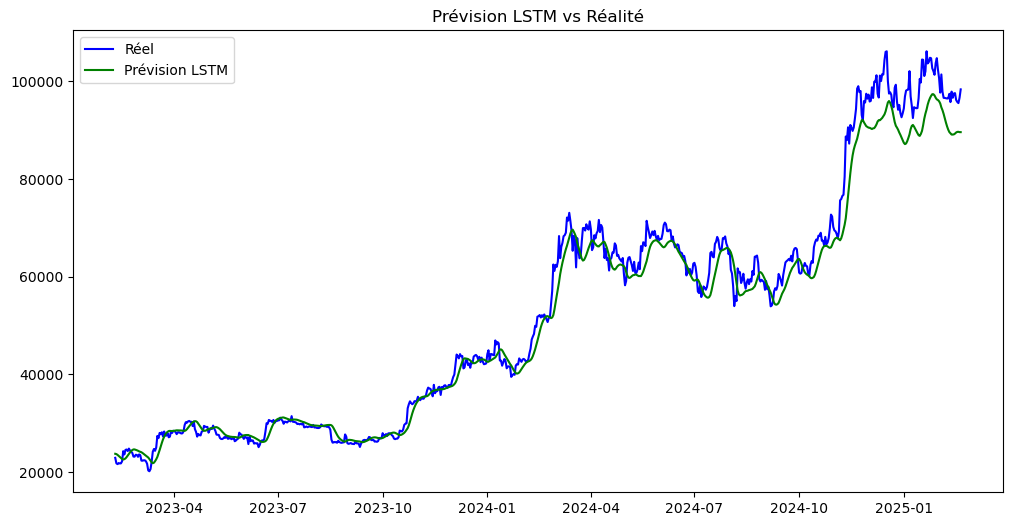

In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Préparation des données pour LSTM (on utilise seulement le prix de clôture)
scaler = MinMaxScaler()
close_scaled = scaler.fit_transform(df_ml[['Close']])

# Création de séquences (fenêtres de 60 jours pour prédire le jour suivant)
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(close_scaled, seq_length)

# Split train/test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Construction du modèle LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))  # Première couche LSTM
model_lstm.add(LSTM(50))                                                     # Deuxième couche LSTM
model_lstm.add(Dense(1))                                                     # Couche de sortie
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Entraînement (5 epochs seulement pour la démo rapide)
model_lstm.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

# Prévisions
pred_scaled = model_lstm.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)

# Graphique
plt.figure(figsize=(12,6))
plt.plot(df_ml.index[train_size+seq_length:], df_ml['Close'][train_size+seq_length:], label='Réel', color='blue')
plt.plot(df_ml.index[train_size+seq_length:], pred, label='Prévision LSTM', color='green')
plt.title('Prévision LSTM vs Réalité')
plt.legend()
plt.show()

In [39]:
# ======================== CALCUL DES MÉTRIQUES ========================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# On récupère les vraies valeurs et les prédictions (déjà créées dans la cellule LSTM)
y_true = df_ml['Close'][train_size + seq_length:].values      # Prix réel
y_pred = pred.flatten()                                       # Prix prédit par le LSTM

# 1. MAE - Mean Absolute Error (Erreur Absolue Moyenne)
mae = mean_absolute_error(y_true, y_pred)

# 2. RMSE - Root Mean Square Error (Racine de l'erreur quadratique moyenne)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# 3. MAPE - Mean Absolute Percentage Error (Erreur en pourcentage)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 4. Directional Accuracy (précision de la direction : monte ou descend ?)
direction_true = np.sign(np.diff(y_true))          # +1 si monte, -1 si descend
direction_pred  = np.sign(np.diff(y_pred))
directional_acc = np.mean(direction_true == direction_pred) * 100

# Affichage des résultats
print("=== MÉTRIQUES DU MODÈLE LSTM ===")
print(f"MAE   (erreur moyenne en dollars) : {mae:,.2f} $")
print(f"RMSE  (erreur quadratique)        : {rmse:,.2f} $")
print(f"MAPE  (erreur en pourcentage)     : {mape:.2f} %")
print(f"Directional Accuracy (direction)  : {directional_acc:.2f} %")
print(f"\nLe modèle a été testé sur les {len(y_true)} derniers jours.")

=== MÉTRIQUES DU MODÈLE LSTM ===
MAE   (erreur moyenne en dollars) : 2,534.75 $
RMSE  (erreur quadratique)        : 3,721.28 $
MAPE  (erreur en pourcentage)     : 4.28 %
Directional Accuracy (direction)  : 46.30 %

Le modèle a été testé sur les 744 derniers jours.
